In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import os
from scipy.stats import kendalltau
from scipy import stats
import numpy as np

In [2]:
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

'''
# load flow data into dataframe
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)
flow_df = flow_df['1969':'2019']
'''
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)
flow_df = flow_df['1969':'2019']

# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]


In [3]:
flow_df

,71132,46618,64602,71135,77505,16501,1043427,71120,71129,62103,...,1043461,71123,57009,95101,65104,29224,79704,75232,64610,93203
date,,,,,,,,,,,,,,,,,,,,,
1969-03-01,69.925630,9108.630435,54464.184783,5249.739130,13777.010870,43206.054348,8920.293478,67.296587,1972.706522,10894.336957,...,7237.717391,109.567348,30804.555556,64368.728261,33040.847826,29262.315217,265.558315,31274.239437,57.223402,322598.489130
1969-06-01,57.136859,NaN,52822.228261,3113.500000,15971.065217,37242.065217,10437.021739,51.997239,1158.608696,13637.586957,...,7128.010870,83.576826,37445.428571,74033.782609,30852.217391,26863.630435,281.937815,NaN,215.210804,248690.250000
1969-09-01,77.727681,6187.923077,81621.670330,NaN,17206.538462,68610.373626,10105.560440,100.987385,3015.131868,29266.241758,...,9232.318681,123.545505,74761.615385,92689.956044,45918.054945,22810.857143,307.428429,NaN,101.952736,431193.813187
1969-12-01,126.854667,NaN,53433.611111,10140.600000,15625.933333,74452.633333,6411.977778,115.188267,3521.511111,11397.611111,...,6110.077778,220.276189,36261.600000,69621.666667,32727.800000,23380.177778,317.745689,NaN,51.993344,249363.155556
1970-03-01,79.719870,5159.858696,43721.978261,5047.847826,6934.010870,80567.086957,NaN,71.374326,1830.510870,9271.097826,...,7013.380435,125.156326,20586.869565,51736.739130,22933.456522,26275.380435,245.512457,NaN,443.995043,200322.521739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,NaN,4295.600000,57341.100000,8354.000000,14495.722222,38940.688889,8291.711111,NaN,3330.822222,13441.322222,...,6035.977778,NaN,21565.577778,70480.833333,34513.600000,16060.600000,NaN,13712.222222,302.570233,169420.733333
2019-03-01,NaN,1952.173913,62849.456522,9826.586957,20431.250000,46286.695652,6251.478261,NaN,2948.923913,13547.804348,...,7557.217391,NaN,22761.869565,122758.554348,37078.913043,14580.326087,NaN,12536.358696,229.510348,379698.869565
2019-06-01,NaN,10345.097826,88507.608696,6307.989130,20872.467391,100586.456522,13190.293478,NaN,2572.630435,27099.380435,...,18877.184783,NaN,59794.184783,132343.217391,51653.163043,31492.413043,NaN,43290.326087,758.822033,515798.000000


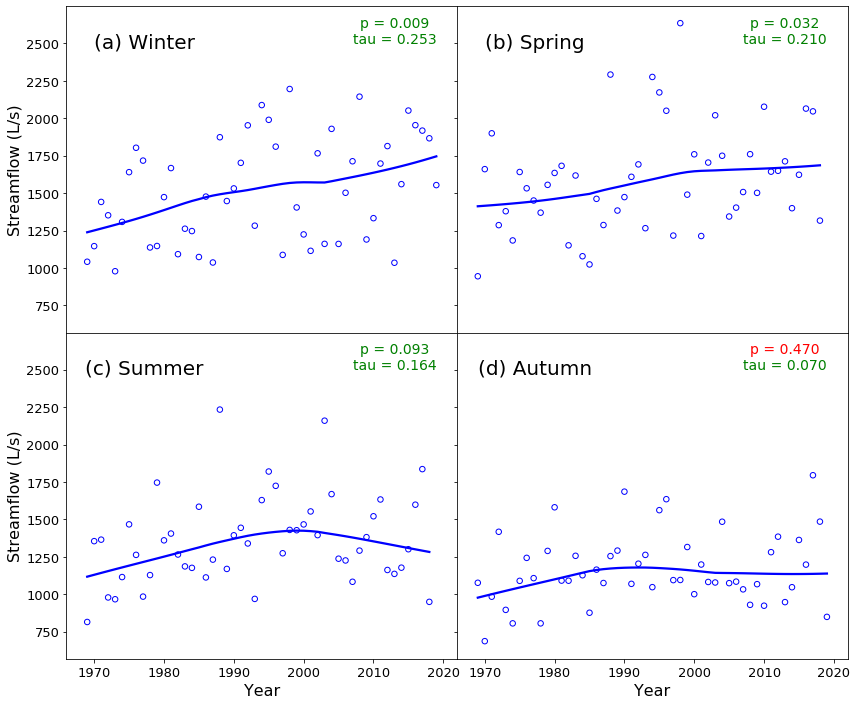

In [3]:
font = {'family': 'sans serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

fig, axs = plt.subplots(2,2, figsize=(14,12), sharex=True, sharey=True)
axs = axs.flatten()

alpha = ['a','b','c','d']
site_flow = flow_df['33347']
for i,s in enumerate(seasons_n):
    
    ax = axs[i]
    
    season_flow = site_flow[site_flow.index.month.isin([s])]
    
    vals = season_flow.values
    years = season_flow.index.year.values

    coef, p = kendalltau(years, vals, nan_policy='omit')

    ax.scatter(years, vals, s=30, facecolors='none', edgecolors='blue', label = 'Annual Mean Flow')
    sns.regplot(years, vals, lowess=True, color = 'blue', label='lowess', scatter=False, ax=ax)

    ax.text(.2, .89, "(" + alpha[i] + ") " + seasons_a[i], fontsize= 20, horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, fontdict=font)
    ax.text(0.84,.95, 'p = ' + "%.3f" % p, horizontalalignment="center", verticalalignment="center", fontsize=14,color="red" if p > 0.1 else 'green', transform=ax.transAxes, fontdict=font)
    ax.text(0.84,.90, 'tau = ' + "%.3f" % coef, horizontalalignment="center", verticalalignment="center", fontsize=14, color = 'green' if coef > 0 else 'red', transform=ax.transAxes, fontdict=font)
    
axs[0].set_ylabel('Streamflow (L/s)', fontdict=font)
axs[2].set_ylabel('Streamflow (L/s)', fontdict=font)
axs[0].tick_params(axis='y',labelsize=13)
axs[2].tick_params(axis='y',labelsize=13)

axs[2].set_xlabel('Year', fontdict=font)
axs[3].set_xlabel('Year', fontdict=font)
axs[2].tick_params(axis='x',labelsize=13)
axs[3].tick_params(axis='x',labelsize=13)

#fig.suptitle('Whanganui at Te Porere (33347) Seasonal Streamflow', y=0.9)

plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig('Figure2.png',dpi=300,bbox_inches='tight')
